# 03a — Phase 2: classifier TRAINING (run rarely)

Trains the local sand/water/whitewater/other MLP per sensor group (TM/OLI/MSI) and
**saves each classifier to Google Drive** — the interface to the extraction
notebook (**03b**), which only *loads* them. A model on Drive survives a Colab
restart, so you train once and never retrain to iterate on extraction.

Thin driver: all logic is in `src/extract.py`. Memory is bounded — training
fetches **one source scene at a time** (`build_training_set_streamed`) and prints
peak RAM, so a full-coast group trains well under Colab's ~12 GB.

**Order:** mount Drive → build `annual` → export scenes for QGIS labelling →
check polygon coverage → train selected groups → visual check.

## Setup — clone-or-pull, authenticate GEE, import & reload `src/`

In [1]:
import os
REPO_DIR = '/content/Shoreline-Dynamics'
# Clone-or-pull so Colab always runs the latest committed code.
if os.path.isdir(REPO_DIR):
    !cd {REPO_DIR} && git pull -q
else:
    !git clone https://github.com/SKPrince1911/Shoreline-Dynamics.git {REPO_DIR}
%cd {REPO_DIR}
!pip install -q -r requirements.txt

Cloning into '/content/Shoreline-Dynamics'...
remote: Enumerating objects: 446, done.
remote: Counting objects: 100% (220/220), done.
remote: Compressing objects: 100% (180/180), done.
remote: Total 446 (delta 155), reused 68 (delta 40), pack-reused 226 (from 1)
Receiving objects: 100% (446/446), 9.02 MiB | 17.58 MiB/s, done.
Resolving deltas: 100% (297/297), done.
/content/Shoreline-Dynamics
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 4.9/4.9 MB 29.8 MB/s eta 0:00:00


In [2]:
import ee, geemap
ee.Authenticate()
ee.Initialize(project='shoreline-analysis')
print('GEE initialized:', ee.String('ok').getInfo())

GEE initialized: ok


In [3]:
import sys; sys.path.append('.')
import importlib
import numpy as np, pandas as pd, geopandas as gpd
import matplotlib.pyplot as plt
from src import config, data, extract
# Pick up freshly pulled modules without a kernel restart (config before its
# dependents). extract is on the reload list so edits to src/extract.py land.
importlib.reload(config); importlib.reload(data); importlib.reload(extract)

aoi = ee.Geometry.Polygon(config.aoi_coordinates())
print('feature dim:', extract.feats_dim(),
      '| default index:', config.WATER_INDEX_DEFAULT,
      '| threshold:', config.THRESHOLD_METHOD_DEFAULT)
print('sensor groups:', extract.SENSOR_GROUP)

feature dim: 20 | default index: mndwi | threshold: otsu
sensor groups: {'L4': 'TM', 'L5': 'TM', 'L7': 'TM', 'L8': 'OLI', 'L9': 'OLI', 'S2': 'MSI'}


## Mount Google Drive

Mount Drive so trained classifiers and exports read from / write to
`/content/drive/MyDrive/shoreline_dynamics/` and **survive a runtime restart**.
Skip only if you deliberately want everything under the (wiped-on-restart) repo
`models/`/`outputs/`.

In [4]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


## Scene list — Series A (annual)

Series A explodes the approved inventory into one row per **acquisition date**
(same-overpass granules mosaicked; multi-date composites split), so every scene
keeps its own timestamp for Phase 3.

In [5]:
# Cached to Drive (then local outputs/); rebuilt from the inventory if absent — fast.
annual = extract.get_scene_list_annual()
n_years = annual['dry_year'].nunique()
print(f'Series A: {len(annual)} scenes across {n_years} dry-season-years')
assert n_years == 38, f'expected 38 non-gap years, got {n_years}'
assert annual['acq_datetime_utc'].notna().all(), 'found a NaT timestamp!'
print('sensors:', annual['sensor'].value_counts().to_dict())

loaded scene_list_annual.csv from cache (60 scenes) <- /content/drive/MyDrive/shoreline_dynamics/cache/scene_list_annual.csv
Series A: 60 scenes across 38 dry-season-years
sensors: {'L5': 35, 'L7': 10, 'S2': 8, 'L8': 6, 'L9': 1}


## Fetch / visual-QC helpers

In [6]:
from shapely.geometry import box
demo_ll = box(92.00, 21.33, 92.06, 21.42)     # (minlon, minlat, maxlon, maxlat)
demo_utm = extract._to_utm(demo_ll)

def rgb_from_scene(sc, pmin=2, pmax=98):
    # Per-scene 2-98% contrast stretch on the VALID pixels (a fixed 0..0.3 stretch
    # looks flat on turbid GBM water). Invalid pixels -> black.
    rgb = np.dstack([sc.bands['red'], sc.bands['green'], sc.bands['blue']]).astype('float32')
    fin = np.isfinite(rgb).all(axis=2)
    if fin.any():
        lo, hi = np.nanpercentile(rgb[fin], [pmin, pmax])
        if not (hi > lo):
            lo, hi = 0.0, 0.3
    else:
        lo, hi = 0.0, 0.3
    return np.nan_to_num(np.clip((rgb - lo) / (hi - lo), 0, 1), nan=0.0)

def show_scene(sc, title=''):
    fig, ax = plt.subplots(1, 2, figsize=(13, 6))
    ax[0].imshow(rgb_from_scene(sc)); ax[0].set_title(title + ' — true colour (2-98%)')
    ax[0].axis('off')
    ax[1].imshow(sc.valid.astype(float), cmap='gray', vmin=0, vmax=1)
    ax[1].set_title('valid mask (white = usable)'); ax[1].axis('off')
    plt.tight_layout(); plt.show()
    print(title, sc.sensor, sc.image_id[:44], '| acq', sc.acq_datetime_utc,
          '| georef', sc.georef_rmse_m, 'm | valid %.1f%%' % (100 * sc.valid.mean()))

def row_for(df, sensor=None, dry_year=None):
    q = df
    if sensor is not None: q = q[q['sensor'] == sensor]
    if dry_year is not None: q = q[q['dry_year'] == dry_year]
    return q.iloc[0] if len(q) else None

def first_covering(df, window_ll, sensor=None, dry_year=None):
    # First scene whose granule footprint intersects window_ll (a single Landsat
    # scene images only part of the AOI: WRS-2 paths 135 & 136).
    q = df
    if sensor is not None: q = q[q['sensor'] == sensor]
    if dry_year is not None: q = q[q['dry_year'] == dry_year]
    minx, miny, maxx, maxy = window_ll.bounds
    win = ee.Geometry.Rectangle([minx, miny, maxx, maxy])
    for _, r in q.iterrows():
        gid = str(r['image_id']).split(',')[0]
        if ee.Image(extract._ee_asset_id(gid, r['sensor'])).geometry().intersects(win, 1).getInfo():
            return r
    print('no', sensor or '', 'scene intersects the demo window — skipping')
    return None

## Export scenes as GeoTIFFs for QGIS labelling (one per source scene)

Each scene is written on the exact EPSG:32646 grid the pipeline extracts from, so
polygons digitised over it line up pixel-for-pixel. **When you digitise, tag each
polygon with `src_year` and `src_sensor`** matching the exported scene (printed
below) — training samples every polygon on ITS OWN scene. Edit `EXPORT_SCENES` to
add the specific scenes you want to label.

**One classifier per band-layout group:** MSI = S2, **OLI = L8 + L9** (same band
layout), **TM = L4 / L5 / L7** (ETM+ shares the TM band set). So a scene labelled
on L9 trains `clf_OLI`, used for both L8 and L9. Defaults shown: S2 2023 (MSI),
**L9 2022 (OLI** — the clean single-date OLI product `LC09_136045/046_20211119`,
100% coverage, 0% cloud**)**, and L5 2006 & 2009 (TM).

In [ ]:
export_dir = ('/content/drive/MyDrive/shoreline_dynamics'
              if os.path.isdir('/content/drive/MyDrive') else 'outputs')
os.makedirs(export_dir, exist_ok=True)
# (sensor, dry_year) scenes to export for labelling — one GeoTIFF each.
# OLI = L8+L9 (same band layout); L9 2022 is the clean single-date OLI product.
EXPORT_SCENES = [('S2', 2023), ('L9', 2022), ('L5', 2006), ('L5', 2009)]
# Full coastal ribbon once the search zone exists, else the small demo window.
region = None if os.path.exists(config.SEARCH_ZONE_PATH) else demo_utm
for sensor, yr in EXPORT_SCENES:
    row = row_for(annual, sensor=sensor, dry_year=yr)
    if row is None:
        print(f'{sensor} {yr}: no scene in the inventory -> skip')
        continue
    tif = os.path.join(export_dir, f'scene_{yr}_{sensor}_utm46n.tif')
    extract.export_scene_geotiff(row, tif, bands=('red', 'green', 'blue', 'swir1'),
                                 region_utm=region)
    print(f'{sensor} {yr}: wrote {tif}')
    print(f'   -> label in QGIS, tag polygons src_year={yr}, src_sensor={sensor!r}')

## Polygon quality — counts per (src_year, src_sensor, class)

Flags `thin` cells (fewer than `min_polys`). Aim for enough of every class on every
labelled scene, especially **sand** and **water** (they drive the ≥0.90 gate).

In [7]:
TRAIN_PATH = 'data/training_polygons.geojson'
if os.path.exists(TRAIN_PATH):
    summ = extract.training_polygon_summary(TRAIN_PATH, min_polys=3)
    print('polygons per (src_year, src_sensor, class):')
    print(summ.to_string(index=False))
    thin = summ[summ['thin']]
    if len(thin):
        print('\nTHIN cells (add more polygons here):')
        print(thin.to_string(index=False))
else:
    print('BLOCKED:', TRAIN_PATH, 'not found — export scenes above, digitise in QGIS,')
    print('tag src_year/src_sensor, upload via GitHub, then `git pull` and re-run.')

polygons per (src_year, src_sensor, class):
 src_year src_sensor      class  n_polys  thin
     2006         L5      other       17 False
     2006         L5       sand       70 False
     2006         L5      water       13 False
     2006         L5 whitewater       40 False
     2022         L9      other       39 False
     2022         L9       sand       84 False
     2022         L9      water       42 False
     2022         L9 whitewater       62 False
     2023         S2      other       58 False
     2023         S2       sand      166 False
     2023         S2      water      118 False
     2023         S2 whitewater      249 False


## Train selected groups → save to Drive

`TRAIN_GROUPS` selects which sensor groups to (re)train; `FORCE_RETRAIN=False`
skips any group whose model is already on Drive (so you never retrain by accident).
For each group `extract.train_group` streams its source scenes **one at a time**
(bounded RAM, peak printed per scene), trains, **saves `clf_<group>_v1.joblib` to
Drive**, evaluates on a held-out scene, and reports the per-class **≥0.90
precision/recall gate** for sand & water. Empty groups are skipped gracefully.

In [11]:
TRAIN_GROUPS = ['TM']      # <-- select groups to train: any of 'MSI','OLI','TM'
FORCE_RETRAIN = False       # <-- True to retrain even if a Drive model exists

if not os.path.exists(TRAIN_PATH):
    print('BLOCKED:', TRAIN_PATH, 'not found (see the polygon-quality cell).')
    results = {}
else:
    results = {}
    for group in TRAIN_GROUPS:
        print(f'\n===== {group} =====')
        # region_utm omitted -> train_group fetches each scene over just its own
        # polygons' bbox (bounded RAM), one scene at a time.
        results[group] = extract.train_group(group, annual, force_retrain=FORCE_RETRAIN)
    print('\nstatus:', {g: r.get('status') for g, r in results.items()})
    print('gate  :', {g: r.get('gate_pass') for g, r in results.items() if r.get('status') == 'trained'})


===== TM =====
TM: training from 1 source scene(s), one at a time ...
  [train 1/1] LT05_136045_20051125,LT05_1360: +13143 samples | rss=566 MB (peak 2809 MB)
TM: 13143 samples | per class {0: 919, 1: 1204, 2: 1227, 3: 9793}
saved classifier -> /content/drive/MyDrive/shoreline_dynamics/models/clf_TM_v1.joblib

TM evaluation (random 80/20 split (single source scene)):
              precision    recall  f1-score   support

       other       1.00      1.00      1.00       178
        sand       1.00      1.00      1.00       232
  whitewater       1.00      0.99      0.99       262
       water       1.00      1.00      1.00      1957

    accuracy                           1.00      2629
   macro avg       1.00      1.00      1.00      2629
weighted avg       1.00      1.00      1.00      2629

TM GATE (sand & water precision AND recall >= 0.90): PASS

status: {'TM': 'trained'}
gate  : {'TM': True}


## Visual check — one classified scene per group

Set `CHECK_GROUP` and re-run to eyeball a classification (sand yellow / water blue /
whitewater white) over the demo window. Loads the model from Drive; never trains.

loaded classifier <- /content/drive/MyDrive/shoreline_dynamics/models/clf_OLI_v1.joblib


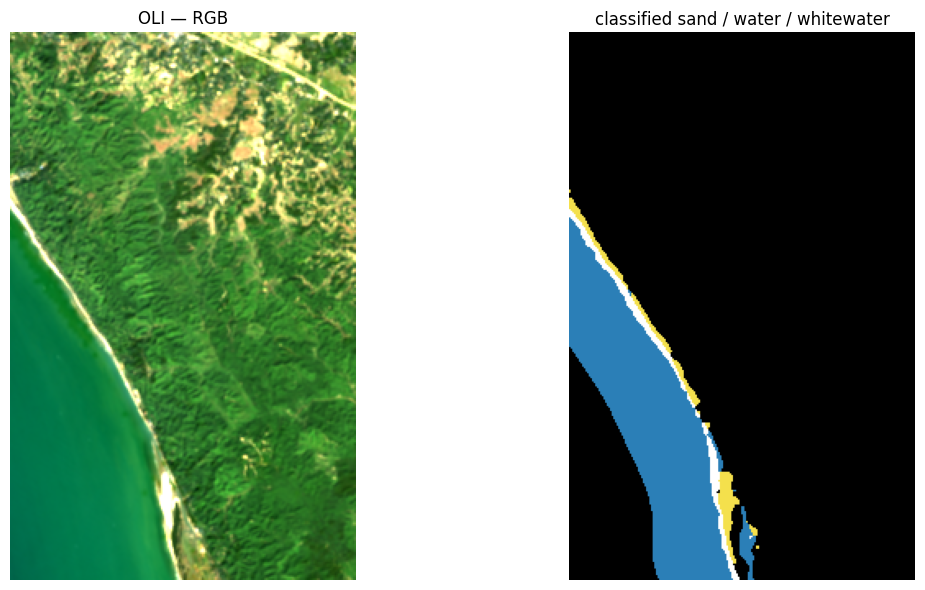

In [14]:
CHECK_GROUP = 'OLI'    # <-- 'MSI' | 'OLI' | 'TM'
# OLI = L8+L9 (L9 exists in the inventory; L8 has no clean single-date product here);
# TM = L4/L5/L7. clf_OLI/clf_TM classify any sensor in their group.
_sensor = {'MSI': 'S2', 'OLI': 'L9', 'TM': 'L5'}[CHECK_GROUP]
if not extract.model_exists(CHECK_GROUP):
    print(f'{CHECK_GROUP}: no trained model on Drive yet — train it above.')
else:
    # first_covering returns a pandas Series or None -> None-check, never `or`.
    _row = first_covering(annual, demo_ll, sensor=_sensor)
    if _row is None:
        _row = row_for(annual, sensor=_sensor)
    sc = extract.fetch_scene(_row, region_utm=demo_utm)   # demo window: light + fast
    clf = extract.load_classifier(CHECK_GROUP)            # prints the Drive path
    labels = extract.classify_scene(sc, clf)
    overlay = np.zeros(sc.valid.shape + (3,))
    overlay[labels == config.CLASS_SAND] = [0.96, 0.88, 0.30]
    overlay[labels == config.CLASS_WATER] = [0.17, 0.50, 0.72]
    overlay[labels == config.CLASS_WHITEWATER] = [1.0, 1.0, 1.0]
    fig, ax = plt.subplots(1, 2, figsize=(13, 6))
    ax[0].imshow(rgb_from_scene(sc)); ax[0].set_title(f'{CHECK_GROUP} — RGB'); ax[0].axis('off')
    ax[1].imshow(overlay); ax[1].set_title('classified sand / water / whitewater'); ax[1].axis('off')
    plt.tight_layout(); plt.show()

## Operator artifacts (digitise in QGIS, upload via the GitHub web interface)

Upload under `data/` on GitHub, then `git pull` in the setup cell.

**`data/shoreline_search_zone.geojson`** — one polygon (EPSG:4326) enclosing every
plausible shoreline 1988–2025 (±300 m about the present shoreline, widening to
±800–1000 m within ~3 km of the Bakkhali and Naf mouths).

**`data/training_polygons.geojson`** — labelled polygons, `class` ∈ {`other`,
`sand`, `whitewater`, `water`}, each tagged with **`src_year`** and **`src_sensor`**
(the dry-year + sensor of the scene it was digitised over, e.g. 2023 / `S2`). ~6
scenes per sensor group (TM = L4/L5/L7, OLI = L8/L9, MSI = S2), spread along the
AOI; aim for ≥5,000 labelled pixels per class per group.

**`data/reference_shorelines/`** — 10 manually digitised validation shorelines
(LineStrings, EPSG:4326) with an `image_id` matching the scene, along the wet/dry
line. Used by `benchmark_extraction()`.

**`data/baseline.geojson`** — a LineString / MultiLineString landward of and roughly
parallel to the coast, **broken at the Naf and Bakkhali mouths** (transects are
cast per segment, never across a gap). Seaward direction is set automatically from
`config.SEAWARD_REFERENCE_LONLAT`.